# traQmania 03 — Quantum circuits as Q-functions

The [previous notebook](02_q_learning_from_scratch.ipynb) trained a 76-parameter
MLP with double DQN. Here we swap the network for a **variational quantum
circuit (VQC)**: a parameterized circuit whose expectation values act as the
function approximator, with the classical optimizer training its angles.

Using VQCs as Q-functions goes back to
[Chen et al., *Variational Quantum Circuits for Deep Reinforcement Learning*,
IEEE Access 2020](https://research.ibm.com/publications/variational-quantum-circuits-for-deep-reinforcement-learning)
(an IBM Research work). Our architecture additionally uses **data
re-uploading** with trainable input scaling, following
[Skolik, Jerbi & Dunjko, *Quantum agents in the Gym*, Quantum 6, 720 (2022)](https://quantum-journal.org/papers/q-2022-05-24-720/)
and [Pérez-Salinas et al., Quantum 4, 226 (2020)](https://quantum-journal.org/papers/q-2020-02-06-226/);
for a broad overview see the survey by
[Meyer et al., *A Survey on Quantum Reinforcement Learning* (arXiv:2211.03464)](https://arxiv.org/abs/2211.03464).

## The circuit

4 qubits (one per observation feature), and $L = 4$ blocks, each consisting of:

1. **encoding**: $RY(\lambda_{l,i} \cdot s_i)$ on qubit $i$ — the observation
   is re-uploaded in *every* block, with a trainable scale $\lambda_{l,i}$
2. **variational**: $RY(\theta_{l,i,0})\, RZ(\theta_{l,i,1})$ on each qubit
3. **entangling**: a ring of CZ gates

Readout is one expectation per action, $E_a = \langle Z_a \rangle \in [-1, 1]$,
mapped to a Q-value by a classical head $Q_a = w_a E_a + b_a$ (Q-values on this
task reach the hundreds, so a trainable output scale is essential — see Skolik
et al. for why).

In [1]:
# On Binder (QuBins images) this repo arrives via nbgitpuller without being
# pip-installed; install it from GitHub only if the import fails.
try:
    import traqmania  # noqa: F401
except ImportError:
    %pip install -q git+https://github.com/JanLahmann/traQmania

import matplotlib.pyplot as plt
import numpy as np

gates: 64  |  trainable parameters: {'lam': 16, 'theta': 32, 'w': 4, 'b': 4, 'total': 56}


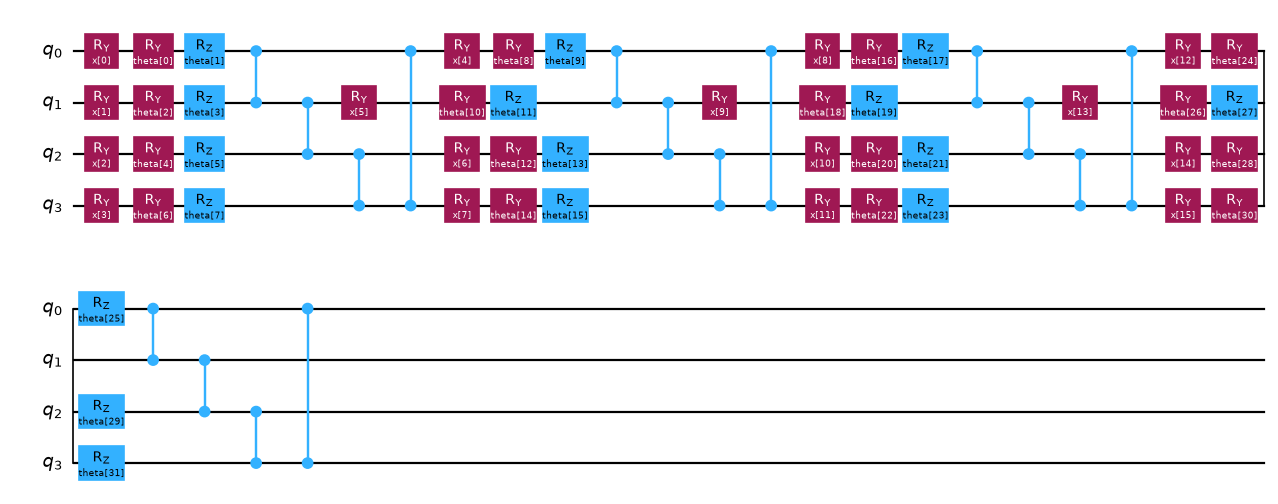

In [2]:
from traqmania.agents.quantum.circuit import build_circuit, circuit_spec

qc = build_circuit(n_qubits=4, n_layers=4)
spec = circuit_spec({"n_qubits": 4, "n_layers": 4})
print(f"gates: {spec['counts']['total']}  |  trainable parameters: {spec['n_params']}")
qc.draw("mpl", fold=23, scale=0.8)

The `x[l*4+i]` angles are the encoding inputs $\lambda_{l,i} s_i$ (the product
is computed outside the circuit, which keeps $\lambda$ trainable while the
circuit stays linear in the bound angle).

## Why re-uploading? Expressivity

A circuit that encodes the input once can only produce a *single-frequency*
sinusoid in each input feature. Each re-upload adds frequencies — the output
becomes a truncated Fourier series whose degree grows with $L$
([Pérez-Salinas et al. 2020](https://quantum-journal.org/papers/q-2020-02-06-226/)).
Let's sweep one input feature (the forward lidar ray) through its range and
watch $\langle Z_1 \rangle$ for circuits with $L = 1, 2, 4$ (random angles):

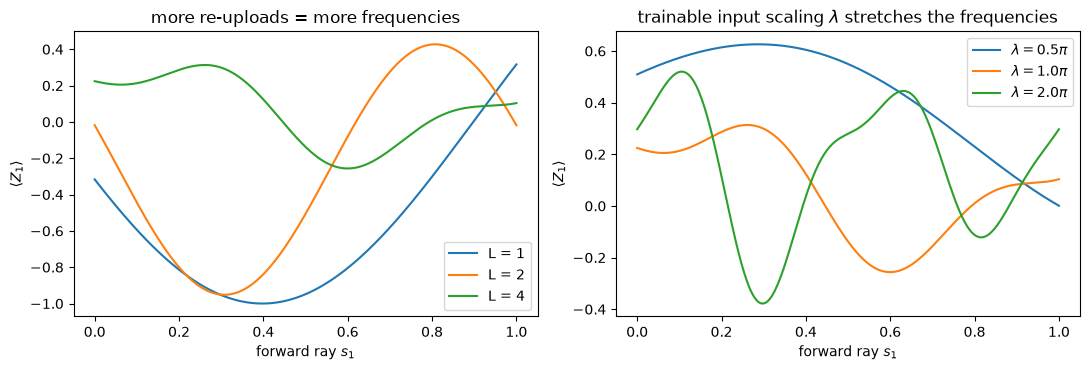

In [3]:
from traqmania.agents.quantum import QuantumQFunction

front = np.linspace(0.0, 1.0, 301)
base_obs = np.array([0.55, 0.0, 0.55, 0.6])  # feature 1 (forward ray) is swept

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
for n_layers in (1, 2, 4):
    qf = QuantumQFunction({"n_qubits": 4, "n_layers": n_layers, "seed": 7})
    qf.theta = np.random.default_rng(3).uniform(-np.pi, np.pi, qf.theta.shape)
    obs = np.tile(base_obs, (front.size, 1))
    obs[:, 1] = front
    ax1.plot(front, qf.expectations(obs)[:, 1], label=f"L = {n_layers}")
ax1.set(xlabel="forward ray $s_1$", ylabel=r"$\langle Z_1 \rangle$",
        title="more re-uploads = more frequencies")
ax1.legend()

qf = QuantumQFunction({"n_qubits": 4, "n_layers": 4, "seed": 7})
qf.theta = np.random.default_rng(3).uniform(-np.pi, np.pi, qf.theta.shape)
for scale in (0.5, 1.0, 2.0):
    qf.lam = np.full(qf.lam.shape, scale * np.pi)
    obs = np.tile(base_obs, (front.size, 1))
    obs[:, 1] = front
    ax2.plot(front, qf.expectations(obs)[:, 1], label=rf"$\lambda = {scale}\pi$")
ax2.set(xlabel="forward ray $s_1$", ylabel=r"$\langle Z_1 \rangle$",
        title=r"trainable input scaling $\lambda$ stretches the frequencies")
ax2.legend()
plt.tight_layout()
plt.show()

Left: with one encoding layer the response is a plain sinusoid; four re-uploads
give a much richer function class. Right: the trainable scales $\lambda$ let
the optimizer choose *which* frequencies to use — the network can sharpen or
flatten its response to each lidar ray.

## Two implementations, one circuit

traQmania has two interchangeable executions of this exact circuit:

- **`fastsim`** — a hand-written numpy statevector simulator with adjoint
  (backpropagation-style) gradients, used for training;
- **`QiskitQFunction`** — the same circuit through Qiskit /
  qiskit-machine-learning's `EstimatorQNN` on Aer, used to validate the fast
  path and to run with shots, noise, and eventually real hardware.

They must agree to numerical precision — let's check that, not assume it:

In [4]:
from traqmania.agents.quantum import make_qfunction

circuit_cfg = {"n_qubits": 4, "n_layers": 4}
fast = QuantumQFunction(circuit_cfg, seed=7)
qnn = make_qfunction("aer_statevector", circuit_cfg, seed=7)  # EstimatorQNN on Aer

obs = np.random.default_rng(1).uniform(0.0, 1.0, size=(8, 4))
diff = np.abs(fast.q_values(obs) - qnn.q_values(obs)).max()
print(f"max |fastsim - EstimatorQNN| over a random batch: {diff:.2e}")
assert diff < 1e-9

max |fastsim - EstimatorQNN| over a random batch: 1.11e-15


## Parameter budget: quantum vs classical

The quantum Q-function has $\lambda$ (16) + $\theta$ (32) + output head
$w, b$ (8) = **56 parameters** — deliberately in the same class as the
76-parameter MLP baseline, so later comparisons are parameter-for-parameter
honest.

In [5]:
from traqmania.agents.classical import MLPQFunction

mlp = MLPQFunction(n_features=4, hidden=8, n_actions=4, seed=0)
print(f"{'':14}{'quantum VQC':>14}{'classical MLP':>16}")
print(f"{'inputs':14}{4:>14}{4:>16}")
print(f"{'outputs':14}{4:>14}{4:>16}")
print(f"{'parameters':14}{fast.n_params:>14}{mlp.n_params:>16}")
print(f"  quantum: lam {fast.lam.size} + theta {fast.theta.size} "
      f"+ w {fast.w.size} + b {fast.b.size}")
print(f"  MLP:     W1 {mlp.W1.size} + b1 {mlp.b1.size} + W2 {mlp.W2.size} + b2 {mlp.b2.size}")

                 quantum VQC   classical MLP
inputs                     4               4
outputs                    4               4
parameters                56              76
  quantum: lam 16 + theta 32 + w 4 + b 4
  MLP:     W1 32 + b1 8 + W2 32 + b2 4


## A teaching point: the provably dead parameters

Look back at the circuit: in the **last block**, each qubit's $RZ$ gate is
followed only by *diagonal* operations — the CZ ring — before the $Z$
measurement. An $RZ$ rotation is itself diagonal, so it **commutes with
everything between it and the observable**: it merely shifts phases that a $Z$
measurement can never see. Its gradient is therefore *exactly zero* for every
input, not just small — those 4 parameters (of the 56) can never train.

Don't take the commutator argument on faith; take the derivative:

In [6]:
rng = np.random.default_rng(2)
obs = rng.uniform(0.0, 1.0, size=(64, 4))
actions = rng.integers(0, 4, size=64)
upstream = rng.normal(size=64)

grad = fast.grad_selected(obs, actions, upstream)      # (56,) flat gradient
dtheta = grad[16:48].reshape(4, 4, 2)                  # (layer, qubit, RY/RZ)

print(f"{'layer':>6}{'max |dL/dRY|':>16}{'max |dL/dRZ|':>16}")
for layer in range(4):
    print(f"{layer:>6}{np.abs(dtheta[layer, :, 0]).max():>16.3e}"
          f"{np.abs(dtheta[layer, :, 1]).max():>16.3e}")
assert np.abs(dtheta[-1, :, 1]).max() < 1e-12, "final-layer RZ should be gradient-dead"
print("\nfinal-layer RZ gradients are exactly zero -- 4 of the 56 parameters are dead weight.")

 layer    max |dL/dRY|    max |dL/dRZ|
     0       5.652e+00       7.403e-01
     1       5.527e+00       5.317e-01
     2       3.641e+00       3.434e-01
     3       2.180e+00       1.205e-17

final-layer RZ gradients are exactly zero -- 4 of the 56 parameters are dead weight.


This is a miniature of a very real phenomenon in variational algorithm design:
ansatz structure interacts with the observable, and parameters can silently do
nothing. (A cheap fix would be to drop the final RZ sublayer or measure
non-diagonal observables; we keep it as the canonical Chen/Skolik-style block
structure — and as a lesson.)

## What gradients cost: param-shift vs adjoint

`EstimatorQNN` computes gradients by the **parameter-shift rule**: two extra
circuit evaluations *per parameter* (2 × 48 circuit parameters, per sample,
per observable). The numpy fast path uses an **adjoint** method — one forward
plus one backward sweep of the statevector for the whole gradient, like
backprop. Same numbers, wildly different cost. Measure it on a small batch:

In [7]:
import time

obs8 = rng.uniform(0.0, 1.0, size=(8, 4))
act8 = rng.integers(0, 4, size=8)
up8 = rng.normal(size=8)

reps = 20
t0 = time.perf_counter()
for _ in range(reps):
    g_fast = fast.grad_selected(obs8, act8, up8)
t_adjoint = (time.perf_counter() - t0) / reps

t0 = time.perf_counter()
g_shift = qnn.grad_selected(obs8, act8, up8)  # param-shift through EstimatorQNN
t_shift = time.perf_counter() - t0

print(f"gradient agreement: max |diff| = {np.abs(g_fast - g_shift).max():.2e}")
print(f"adjoint (fastsim):        {t_adjoint * 1e3:8.1f} ms per batch-8 gradient")
print(f"param-shift (EstimatorQNN): {t_shift:6.1f} s  per batch-8 gradient")
print(f"speedup: ~{t_shift / t_adjoint:,.0f}x")

gradient agreement: max |diff| = 1.89e-15
adjoint (fastsim):             1.7 ms per batch-8 gradient
param-shift (EstimatorQNN):    5.2 s  per batch-8 gradient
speedup: ~3,047x


Identical gradients, three-to-four orders of magnitude apart in cost (on the
full batch-32 double-DQN update the measured gap is **~3.4 ms vs ~20.5 s, about
6000×**). This is *the* practical reason quantum RL research trains on
simulators: a DQN run takes tens of thousands of gradient steps, and
param-shift pricing turns seconds into weeks — before adding hardware queue
time. We return to this trade-off in [notebook 05](05_real_quantum_hardware.ipynb).

**Next:** [04 — Training the quantum driver](04_training_the_quantum_driver.ipynb)
plugs this circuit into the DQN loop from notebook 02 and races it against the
MLP.